In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

1. filter for us and DA job

In [2]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()

2. find job locations in us 

In [3]:
df_DA_US['job_location'].value_counts()
 

job_location
Anywhere          5106
New York, NY      3035
Atlanta, GA       2741
Chicago, IL       2337
Austin, TX        1919
                  ... 
Salem, NJ            1
Leominster, MA       1
Annapolis, IN        1
Webb City, MO        1
Loami, IL            1
Name: count, Length: 3220, dtype: int64

In [5]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
df_plot

,count
job_location,
Anywhere,5106
"New York, NY",3035
"Atlanta, GA",2741
"Chicago, IL",2337
"Austin, TX",1919
"Dallas, TX",1862
"Washington, DC",1592
"Charlotte, NC",1433
"Tampa, FL",1431


<Axes: xlabel='count', ylabel='job_location'>

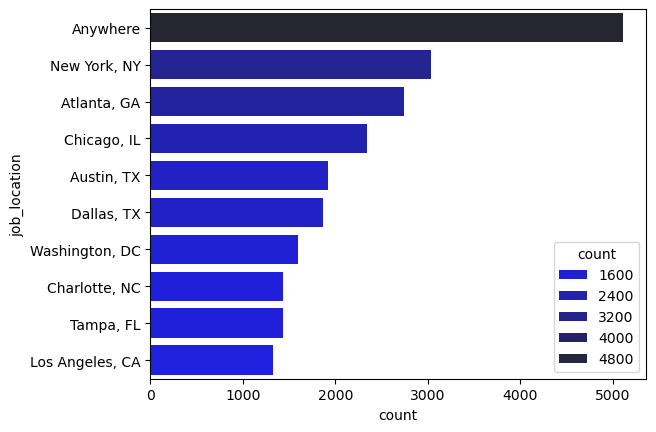

In [7]:
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r')

<Axes: xlabel='count', ylabel='job_location'>

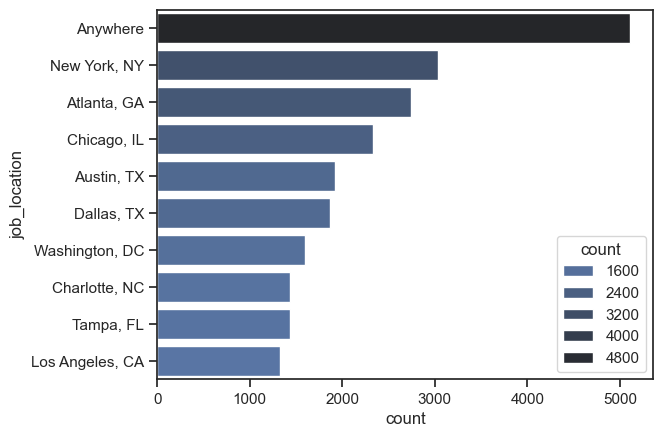

In [8]:
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r')

<Axes: xlabel='count', ylabel='job_location'>

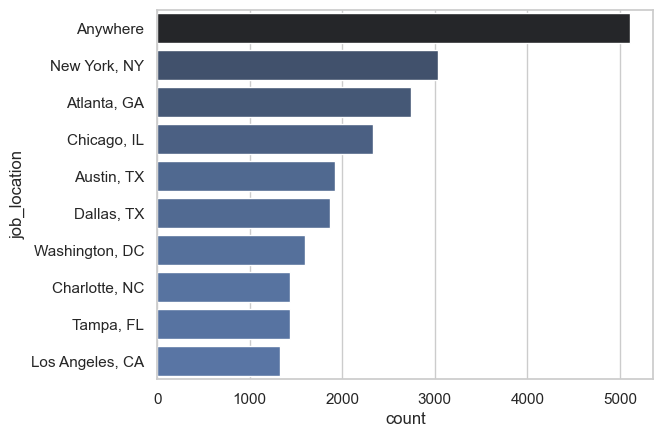

In [ ]:
sns.set_theme(style='whitegrid')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)

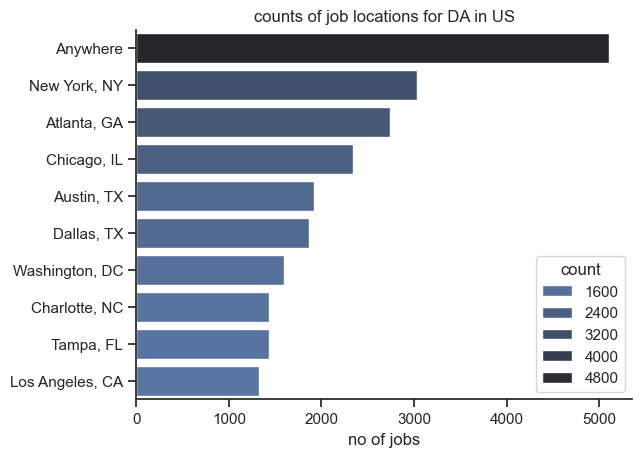

In [12]:
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r')
sns.despine()  #remove the border around the plot
plt.title('counts of job locations for DA in US')
plt.xlabel('no of jobs')
plt.ylabel('')
plt.show()

2. check job having work from home, degree requirement, health issuance offered or not

i have to show pie chart of 3 columns 1. work from home or not etc

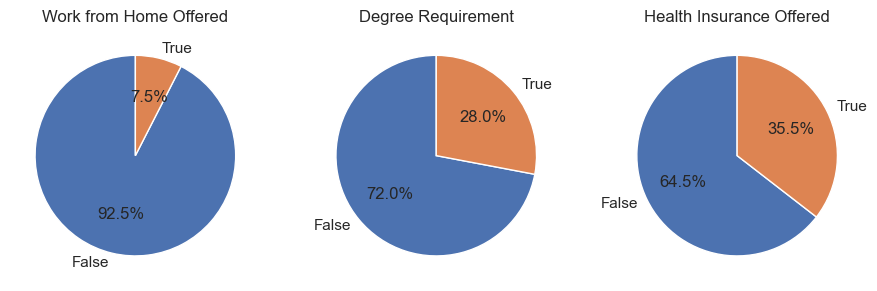

In [15]:
dict_col = {
    'job_work_from_home':'Work from Home Offered',
    'job_no_degree_mention':'Degree Requirement',
    'job_health_insurance':'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

#traverse through the dictionary and plot each column

for i, (col, title) in enumerate(dict_col.items()):
    ax[i].pie(df_DA_US[col].value_counts(), labels=['False', 'True'], autopct = '%1.1f%%', startangle=90)
    ax[i].set_title(title)


3. company names and count

In [16]:
df_plot2 = df_DA_US['company_name'].value_counts().head(10)
df_plot2

company_name
Robert Half                                959
Insight Global                             827
Dice                                       584
UnitedHealth Group                         507
Get It Recruit - Information Technology    503
Citi                                       477
Corporate                                  416
SynergisticIT                              374
Centene Corporation                        350
Booz Allen Hamilton                        315
Name: count, dtype: int64

In [19]:
df_plot2 = df_DA_US['company_name'].value_counts().head(10).to_frame()
df_plot2

,count
company_name,
Robert Half,959
Insight Global,827
Dice,584
UnitedHealth Group,507
Get It Recruit - Information Technology,503
Citi,477
Corporate,416
SynergisticIT,374
Centene Corporation,350


Text(0, 0.5, 'Company Name')

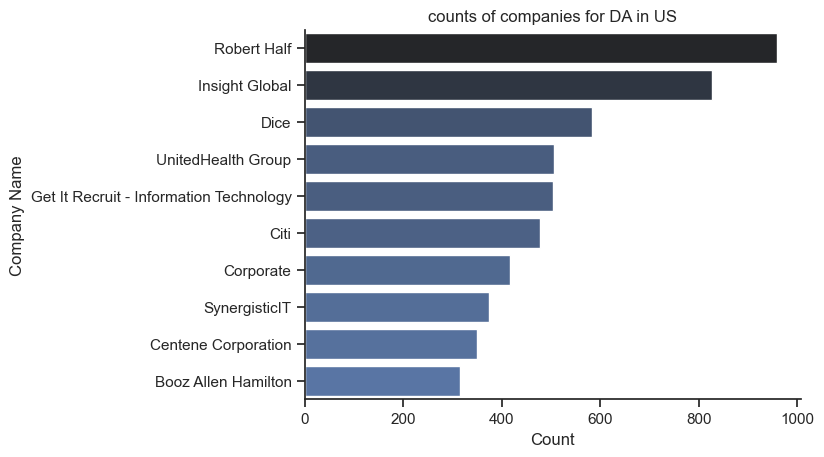

In [20]:
df_plot2 = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot2, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('counts of companies for DA in US')
plt.xlabel('Count')
plt.ylabel('Company Name')
